# Motor Control Tuner
PMSM nested PI loop design — from datasheet to firmware-ready gains.

**Workflow:**
1. Load motor + load config
2. Build plant model
3. Electrical parameter identification (Rs, Ld, Lq, psi_f)
4. Mechanical parameter identification (p, KE_SI, J_total, J_load, B_total, k_fan)
5. Tune current loop (4 methods)
6. Discretization analysis
7. Speed loop (4 methods)
8. Robustness analysis
9. Position loop (P / PD + feedforward)
10. Firmware table + dashboard

In [1]:
# --- Setup: add project root to path ---
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import matplotlib
matplotlib.use('Agg')   # change to 'inline' if running in classic Jupyter
import matplotlib.pyplot as plt
from IPython.display import display, Image

from utils.config import load_config
from modules.plant import PMSMPlant
from modules.param_id import ParameterIdentifier
from modules.current_loop import CurrentLoopTuner
from modules.speed_loop import SpeedLoopTuner
from modules.position_loop import PositionLoopTuner
from modules.discretization import Discretizer
from modules.robustness import RobustnessAnalyser
from modules.dashboard import generate_dashboard

os.makedirs('../outputs', exist_ok=True)
print('Imports OK')

Imports OK


## Cell 1 — Select motor and load
Swap the commented lines to switch motor/load.

In [2]:
# --- SPMSM + Fan load ---
motor_cfg, load_cfg = load_config(
    '../config/motor_delta_ecma_c21010.yaml',
    '../config/load_fan.yaml'
)

# --- IPMSM + Constant torque (uncomment to switch) ---
# motor_cfg, load_cfg = load_config(
#     '../config/motor_magnetic_blq40.yaml',
#     '../config/load_const_torque.yaml'
# )

print(f"Motor : {motor_cfg['name']}  [{motor_cfg['motor_type']}]")
print(f"Load  : {load_cfg['name']}  [{load_cfg['load_type']}]")
print(f"Rs={motor_cfg['electrical']['Rs_ohm']} ohm  "
      f"Ld={motor_cfg['electrical']['Ld_H']*1e3:.3f} mH  "
      f"Lq={motor_cfg['electrical']['Lq_H']*1e3:.3f} mH  "
      f"psi_f={motor_cfg['electrical']['psi_f_Wb']*1e3:.2f} mWb")
print(f"J_total = {motor_cfg['mechanical']['J_kgm2'] + load_cfg['J_load_kgm2']:.4e} kg.m2")

Motor : Delta ECMA-C21010  [SPMSM]
Load  : Fan load (quadratic)  [fan]
Rs=0.2 ohm  Ld=1.810 mH  Lq=1.810 mH  psi_f=43.60 mWb
J_total = 1.0600e-03 kg.m2


## Cell 2 — Plant model

In [3]:
plant = PMSMPlant(motor_cfg, load_cfg)
plant.summary()

# Show current plant transfer functions
num_d, den_d = plant.get_current_plant_tf('d')
num_q, den_q = plant.get_current_plant_tf('q')
print(f"\nG_d(s) = {num_d[0]:.4f} / ({den_d[0]*1e3:.3f}ms * s + 1)")
print(f"G_q(s) = {num_q[0]:.4f} / ({den_q[0]*1e3:.3f}ms * s + 1)")

# MTPA for IPMSM
if plant.motor_type == 'IPMSM':
    import math
    Is = motor_cfg['rated']['current_A']
    id_mtpa, iq_mtpa = plant.mtpa_currents(Is)
    print(f"\nMTPA at Is={Is:.1f} A: id*={id_mtpa:.2f} A, iq*={iq_mtpa:.2f} A  (beta={math.degrees(plant.mtpa_angle(Is)):.1f} deg)")

PMSMPlant: Delta ECMA-C21010  [SPMSM]
  Rs=0.2 ohm  Ld=1.810 mH  Lq=1.810 mH
  psi_f=43.60 mWb  p=4
  tau_d=9.05 ms  tau_q=9.05 ms
  J_total=1.0600e-03 kg*m^2  B_total=1.0000e-03 N*m*s/rad
  Load: Fan load (quadratic)  [fan]
  Kt_eff (3/2*p*psi_f) = 0.2616 N*m/A

G_d(s) = 5.0000 / (9.050ms * s + 1)
G_q(s) = 5.0000 / (9.050ms * s + 1)


## Cell 3 — Electrical parameter identification

Simulates three bench tests with 2% Gaussian noise:
- **Test 1:** DC lockout step → Rs
- **Test 2:** AC standstill injection at 100 Hz → Ld, Lq
- **Test 3:** Open-circuit BEMF at 1000/2000/3000 rpm → psi_f

To use real bench measurements instead of the simulation:
```python
params = pid.override(Rs=0.21, Ld=1.85e-3, Lq=1.85e-3, psi_f=0.044)
```


Parameter Identification Summary [simulated]
Motor: Delta ECMA-C21010
Param              True     Measured  Error %  Unit
----------------------------------------------------
Rs               0.2000       0.2020    +1.01%  Ohm
Ld               1.8100       1.8576    +2.63%  mH
Lq               1.8100       1.9117    +5.62%  mH
psi_f           43.6000      42.7036    -2.06%  mWb

tau_d = 9.195 ms
tau_q = 9.463 ms
Saved: ../outputs/param_id_electrical.png


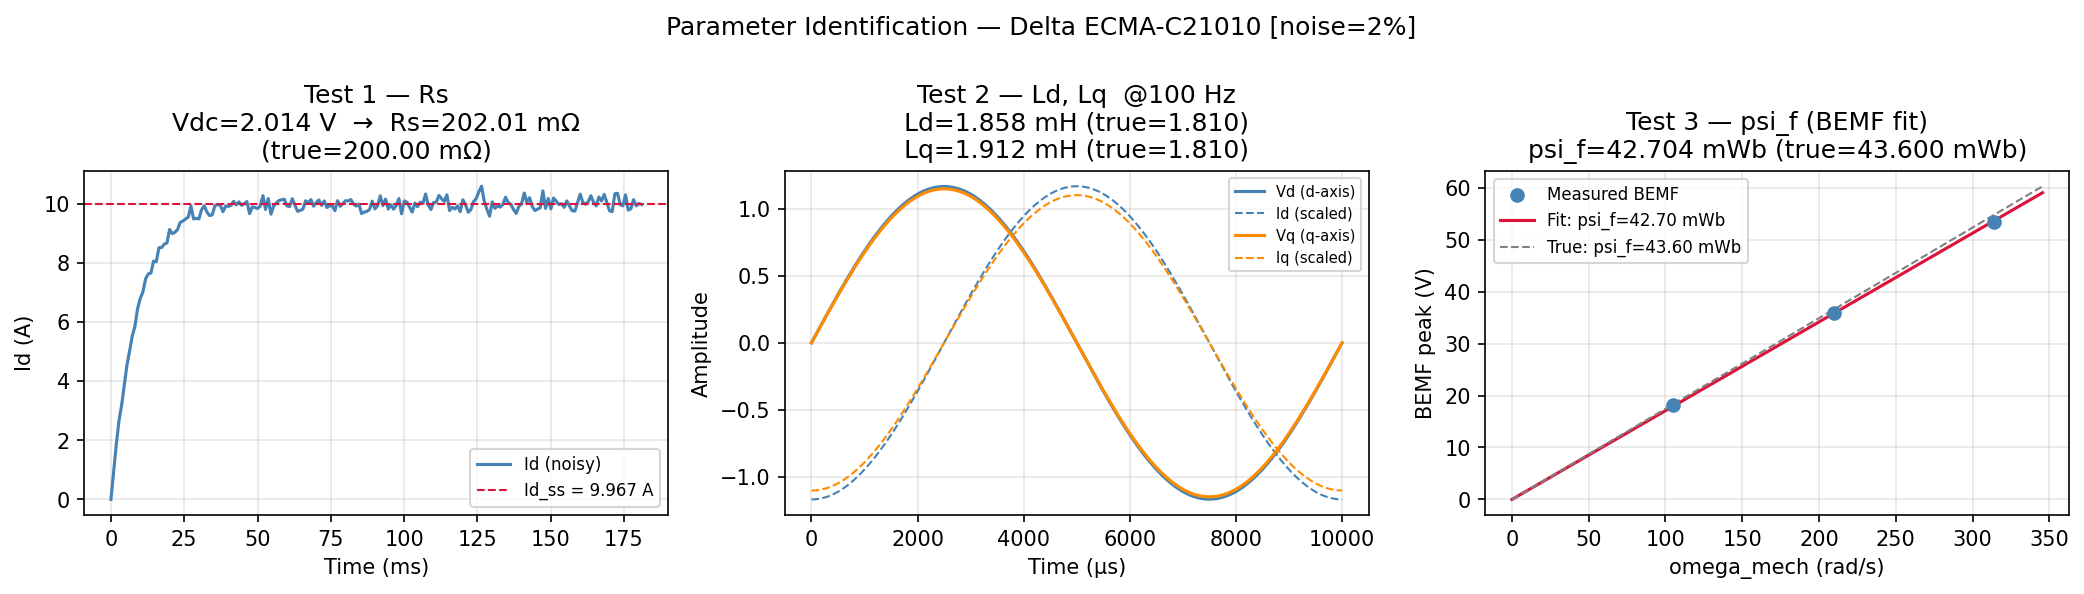

In [4]:
# Pass load_cfg so mechanical identification is also available
pid = ParameterIdentifier(motor_cfg, load_cfg)
params = pid.simulate(noise_std_frac=0.02)

pid.print_comparison(params)

# Electrical identification plots (DC step, AC injection, BEMF fit)
out = '../outputs/param_id_electrical.png'
pid.plot_identification(params, save_path=out)
display(Image(out))

## Cell 4 — Mechanical parameter identification

Simulates four additional bench tests (requires load_cfg):
- **Test 4:** BEMF zero-crossing count at 1000 rpm → p (pole pairs)
- **Test 5:** OLS fit of BEMF slope vs ω → KE_SI (V·s/rad), psi_f refined
- **Test 6:** No-load acceleration step (iq = 1 A, 2 s window) → J_total, J_load
- **Test 7:** Steady-state torque sweep at 10 speeds → B_total + load coefficient
  - Fan load: recovers B_total and k_fan
  - Constant torque: recovers B_total and TL_const
  - Servo load: recovers B_total only

To use real bench measurements:
```python
mech_params = pid.override(p=4, J_total=1.06e-3, B_total=0.001, k_fan=1.12e-5)
```


Parameter Identification Summary [simulated_mechanical]
Motor: Delta ECMA-C21010
Param              True     Measured  Error %  Unit
----------------------------------------------------
Rs               0.2000       0.2020    +1.01%  Ohm
Ld               1.8100       1.8576    +2.63%  mH
Lq               1.8100       1.9117    +5.62%  mH
psi_f           43.6000      42.7036    -2.06%  mWb

tau_d = 9.195 ms
tau_q = 9.463 ms

Mechanical Identification Summary
  Motor:  J_motor=2.6500e-04 kg.m2  B_motor=0.00100 N.m.s/rad
  Load:   J_load_true=7.9500e-04 kg.m2  B_load_true=0.00000 N.m.s/rad

Param                True       Measured  Error %  Unit
----------------------------------------------------------
p                  4.0000         4.0000    +0.00%  -
KE_SI              0.1744         0.1719    -1.41%  V.s/rad
psi_f_ke          43.6000        42.9870    -1.41%  mWb
J_total           10.6000        10.5831    -0.16%  x1e-4 kg.m2
J_load             7.9500         7.9331    -0.21%  x1e

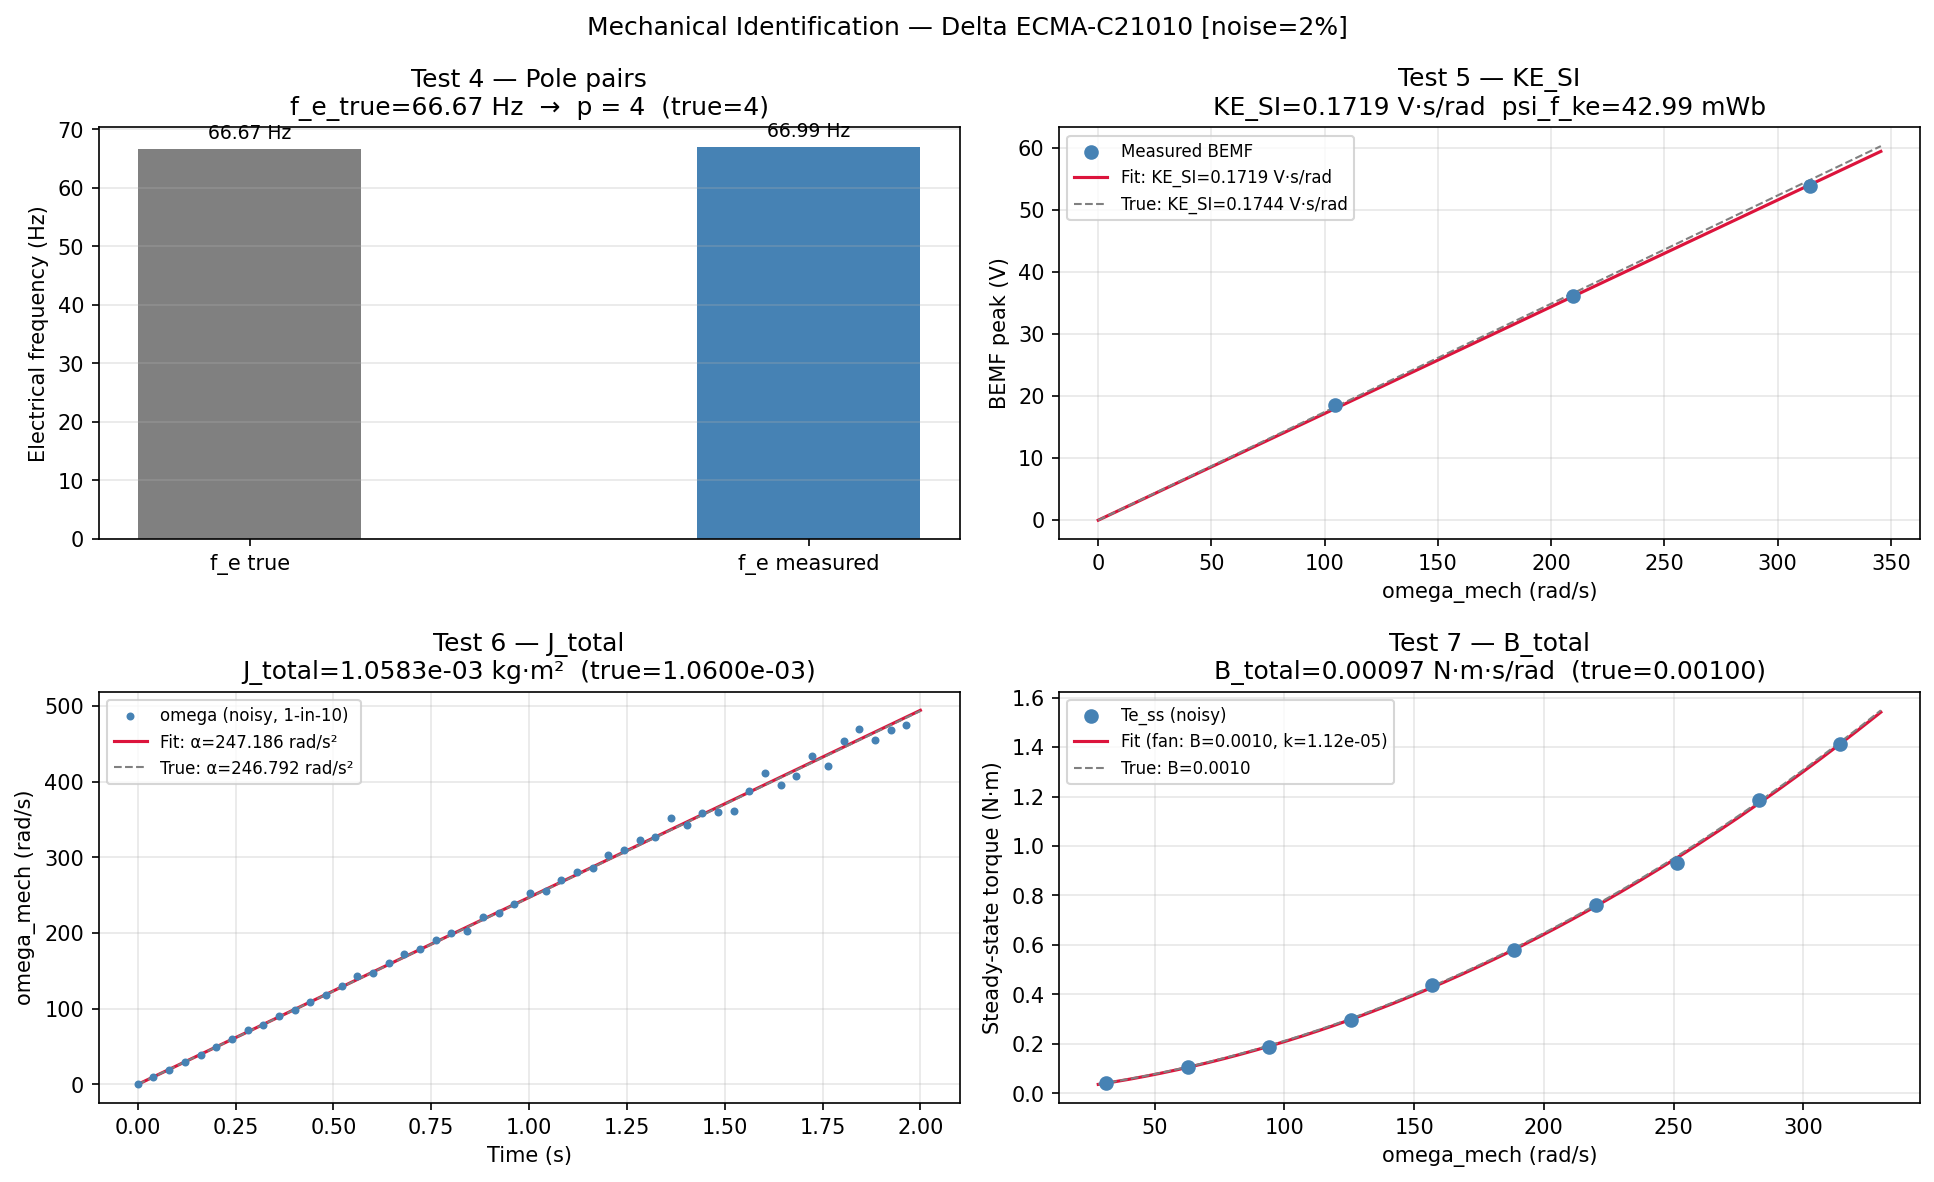

Identified parameters:
  p       = 4
  KE_SI   = 0.1719 V.s/rad
  psi_f_ke= 42.987 mWb  (vs electrical fit: 42.704 mWb)
  J_total = 1.0583e-03 kg.m2  (J_load = 7.9331e-04)
  B_total = 0.00097 N.m.s/rad  (B_load = -0.00003)
  k_fan   = 1.1229e-05 N.m/(rad/s)^2


In [6]:
mech_params = pid.simulate_mechanical(noise_std_frac=0.02)

# Print combined electrical + mechanical comparison table
pid.print_comparison({**params, **mech_params})

# Mechanical identification plots (pole-pairs, KE_SI, J ramp, B sweep)
out = '../outputs/param_id_mechanical.png'
pid.plot_mechanical(mech_params, save_path=out)
display(Image(out))

# Summary of key identified values
print(f"Identified parameters:")
print(f"  p       = {mech_params['p']}")
print(f"  KE_SI   = {mech_params['KE_SI']:.4f} V.s/rad")
print(f"  psi_f_ke= {mech_params['psi_f_ke']*1e3:.3f} mWb  (vs electrical fit: {params['psi_f']*1e3:.3f} mWb)")
print(f"  J_total = {mech_params['J_total']:.4e} kg.m2  (J_load = {mech_params['J_load']:.4e})")
print(f"  B_total = {mech_params['B_total']:.5f} N.m.s/rad  (B_load = {mech_params['B_load']:.5f})")
if mech_params['k_fan'] is not None:
    print(f"  k_fan   = {mech_params['k_fan']:.4e} N.m/(rad/s)^2")
if mech_params['TL_const'] is not None:
    print(f"  TL_const= {mech_params['TL_const']:.4f} N.m")

## Cell 4 — Current loop: all 4 methods compared

In [7]:
tuner_i = CurrentLoopTuner(plant, params)

results_i = {
    'pole_zero':         tuner_i.tune('pole_zero',        axis='d', tau_cl_s=1e-3),
    'frequency_domain':  tuner_i.tune('frequency_domain', axis='d', BW_Hz=500),
    'root_locus':        tuner_i.tune('root_locus',       axis='d', target_zeta=0.707, tau_cl_s=0.5e-3),
    'ziegler_nichols':   tuner_i.tune('ziegler_nichols',  axis='d'),
}

print(f"{'Method':<20} {'Kp':>8} {'Ki':>10} {'BW_Hz':>8} {'PM_deg':>8} {'GM_dB':>8} {'Tset_ms':>9}")
print('-' * 77)
for name, r in results_i.items():
    gm = f'{r.GM_dB:.1f}' if r.GM_dB < 900 else 'inf'
    print(f"{name:<20} {r.Kp:>8.4f} {r.Ki:>10.2f} {r.BW_Hz:>8.1f} {r.PM_deg:>8.1f} {gm:>8} {r.settling_ms:>9.3f}")
    for w in r.warnings:
        print(f'  {w}')

Method                     Kp         Ki    BW_Hz   PM_deg    GM_dB   Tset_ms
-----------------------------------------------------------------------------
pole_zero              1.8576     202.01    158.8     90.0      inf     3.897
frequency_domain       5.8103    1825.36    530.2     86.3      inf     4.414
root_locus             5.0512    7430.34    631.9     66.1      inf     2.449
ziegler_nichols       22.3891  114527.31   2657.6     69.0      inf     0.621


## Cell 5 — Bode plots (all 4 current loop methods)

Saved: ../outputs/bode_current_pole_zero.png
--- pole_zero ---


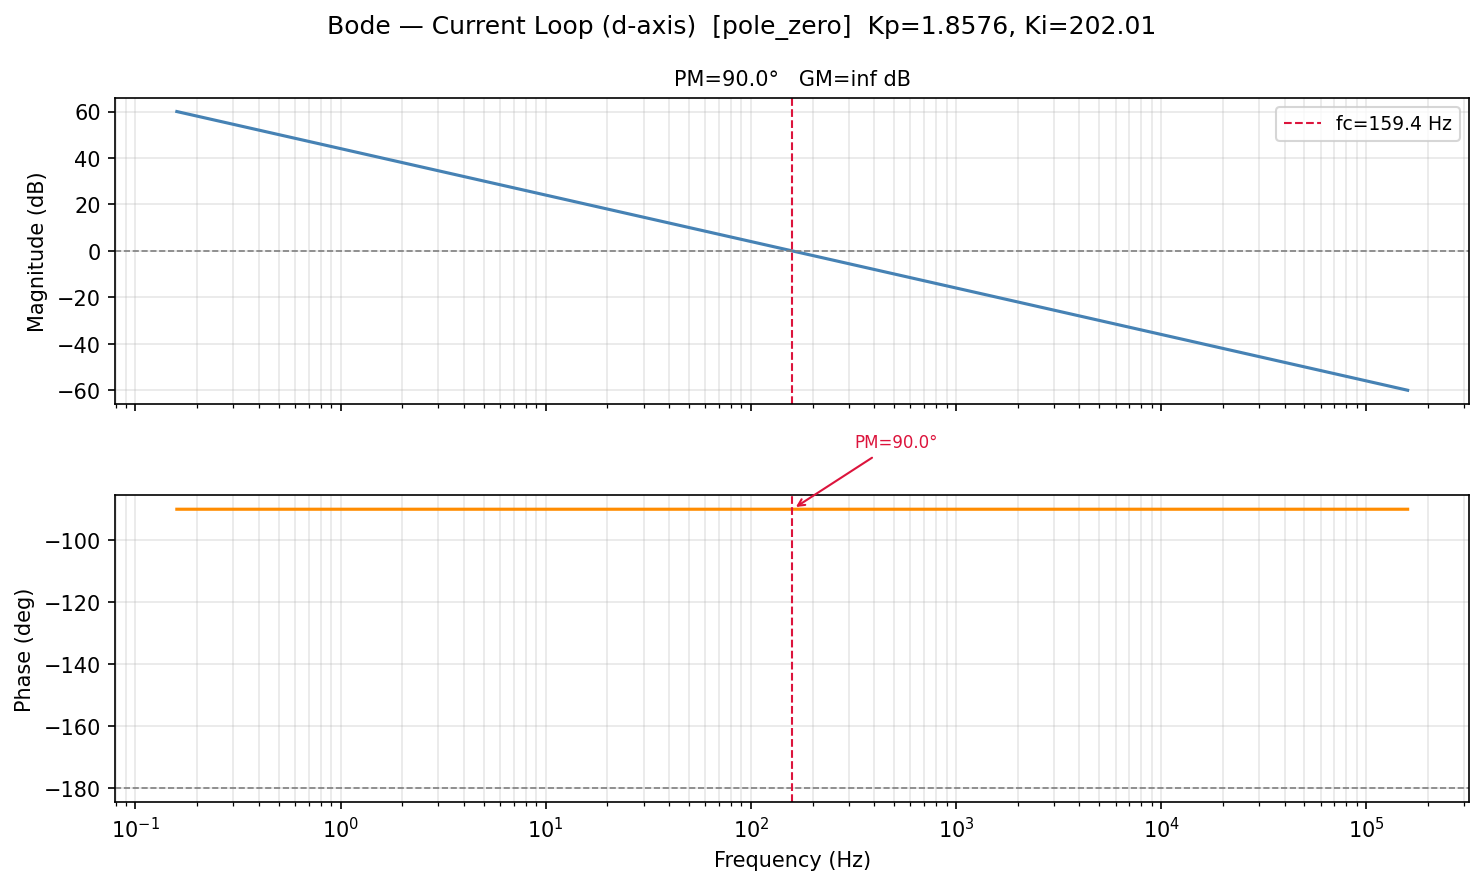

Saved: ../outputs/bode_current_frequency_domain.png
--- frequency_domain ---


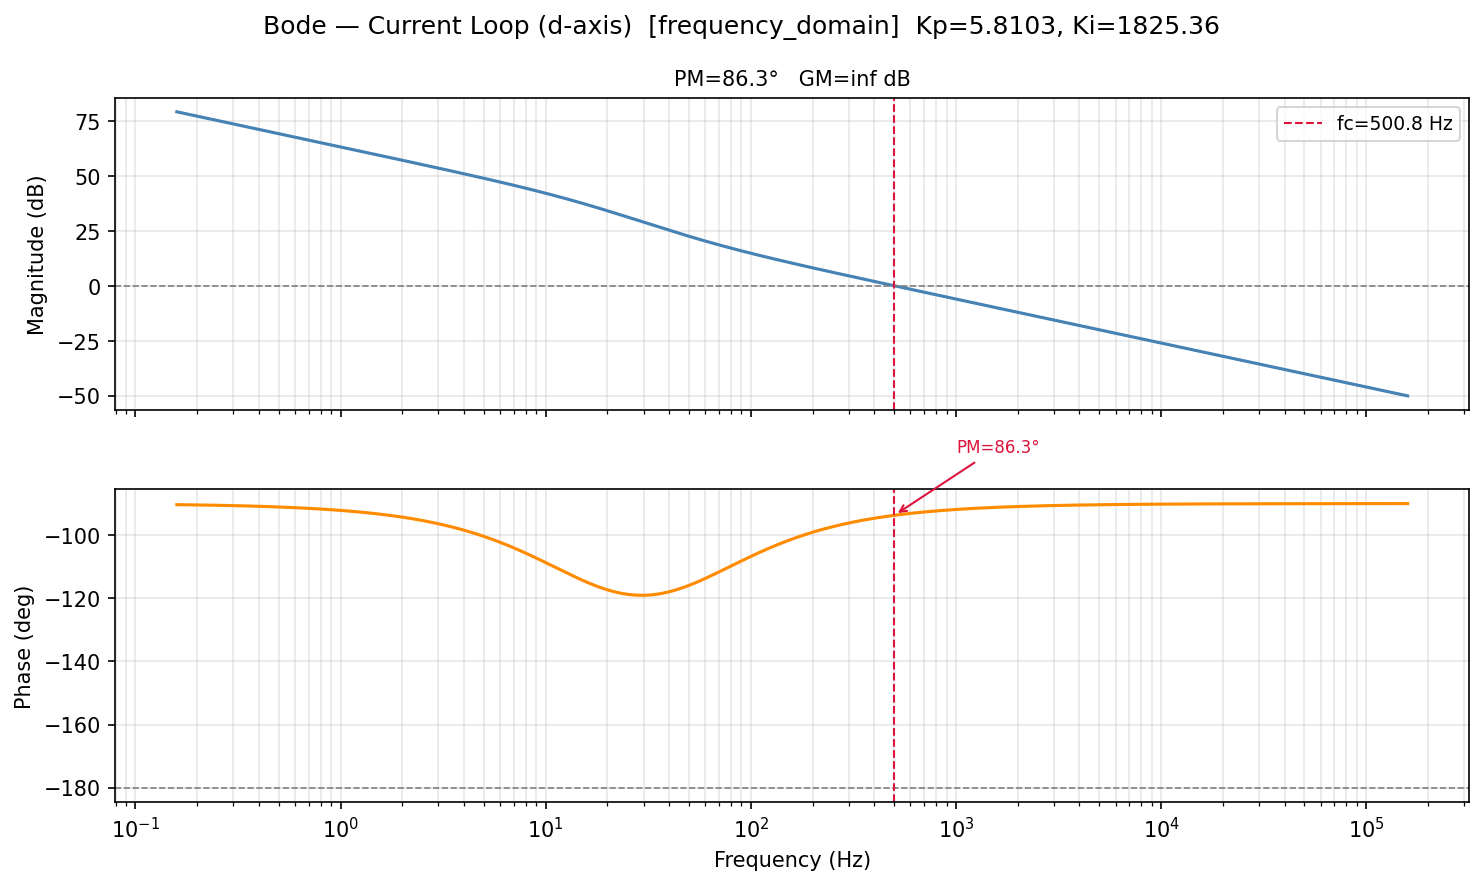

Saved: ../outputs/bode_current_root_locus.png
--- root_locus ---


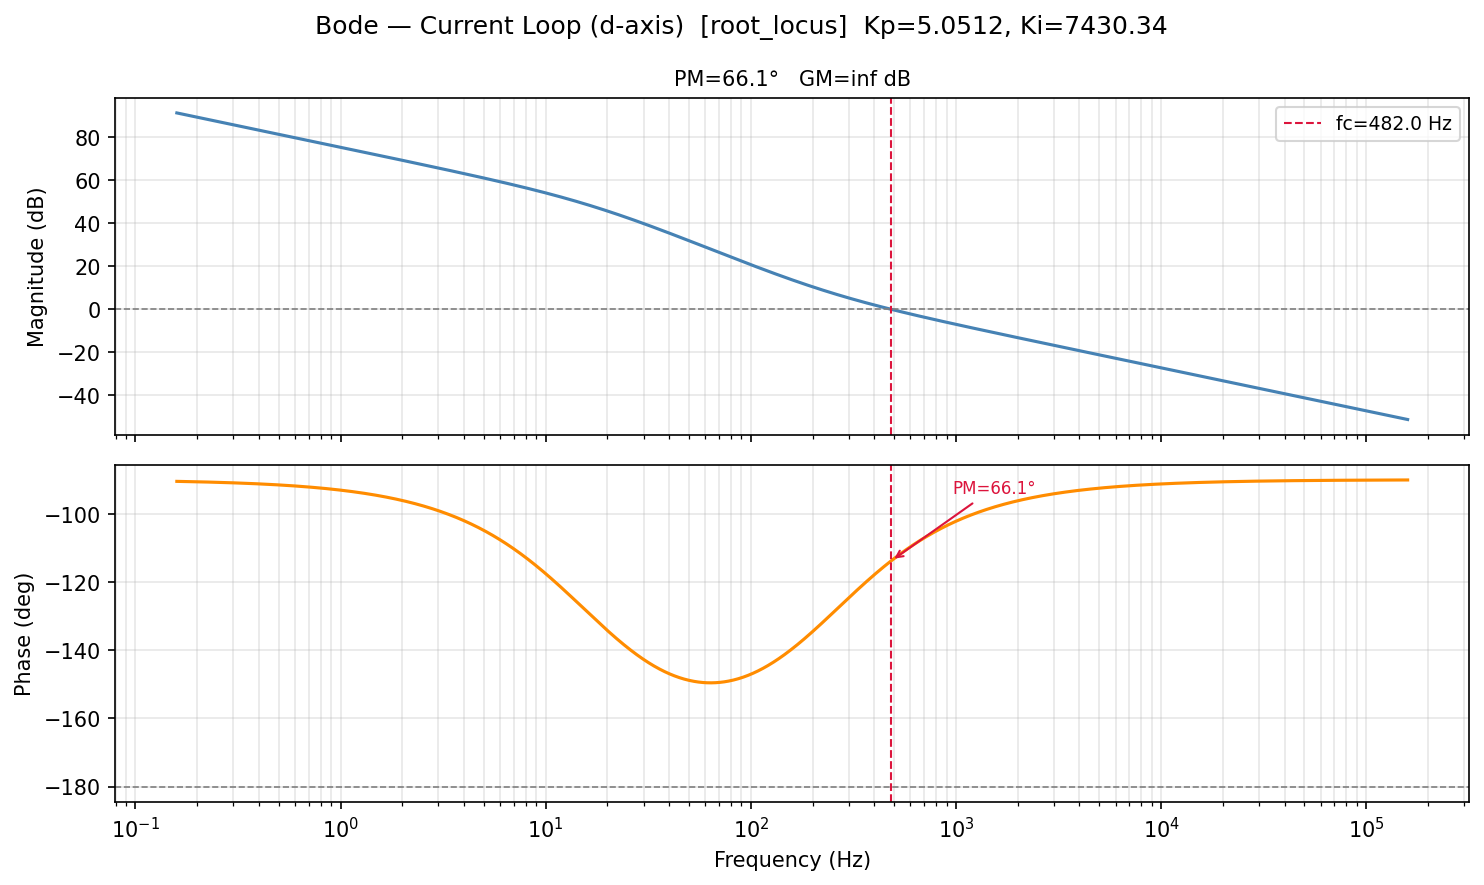

Saved: ../outputs/bode_current_ziegler_nichols.png
--- ziegler_nichols ---


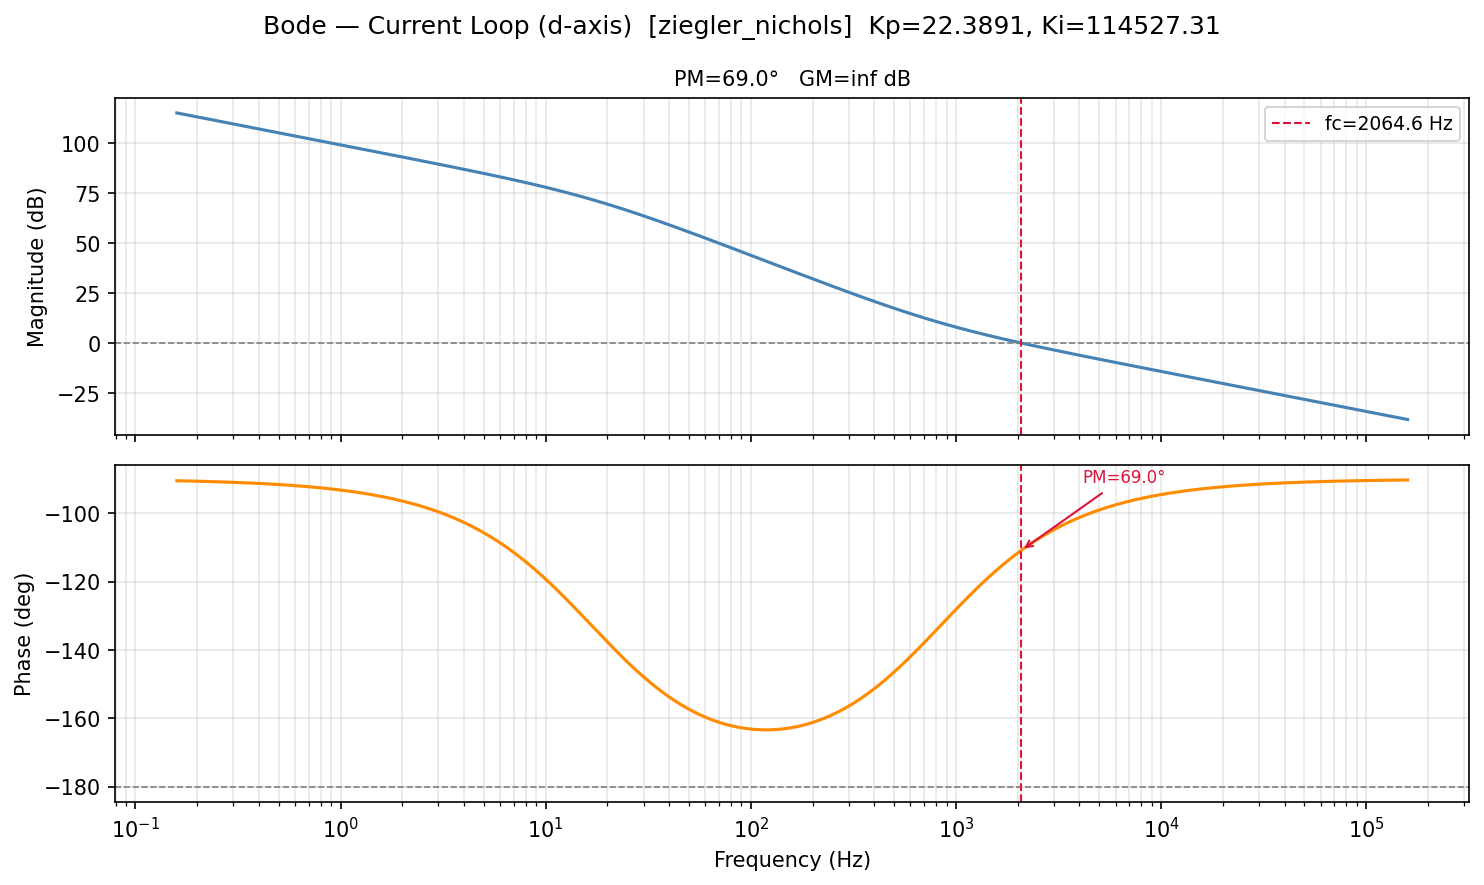

In [8]:
for name, r in results_i.items():
    out = f'../outputs/bode_current_{name}.png'
    r.plot_bode(save_path=out)
    print(f'--- {name} ---')
    display(Image(out))

## Cell 6 — Step responses (all 4 current loop methods)

Saved: ../outputs/step_current_pole_zero.png
--- pole_zero ---


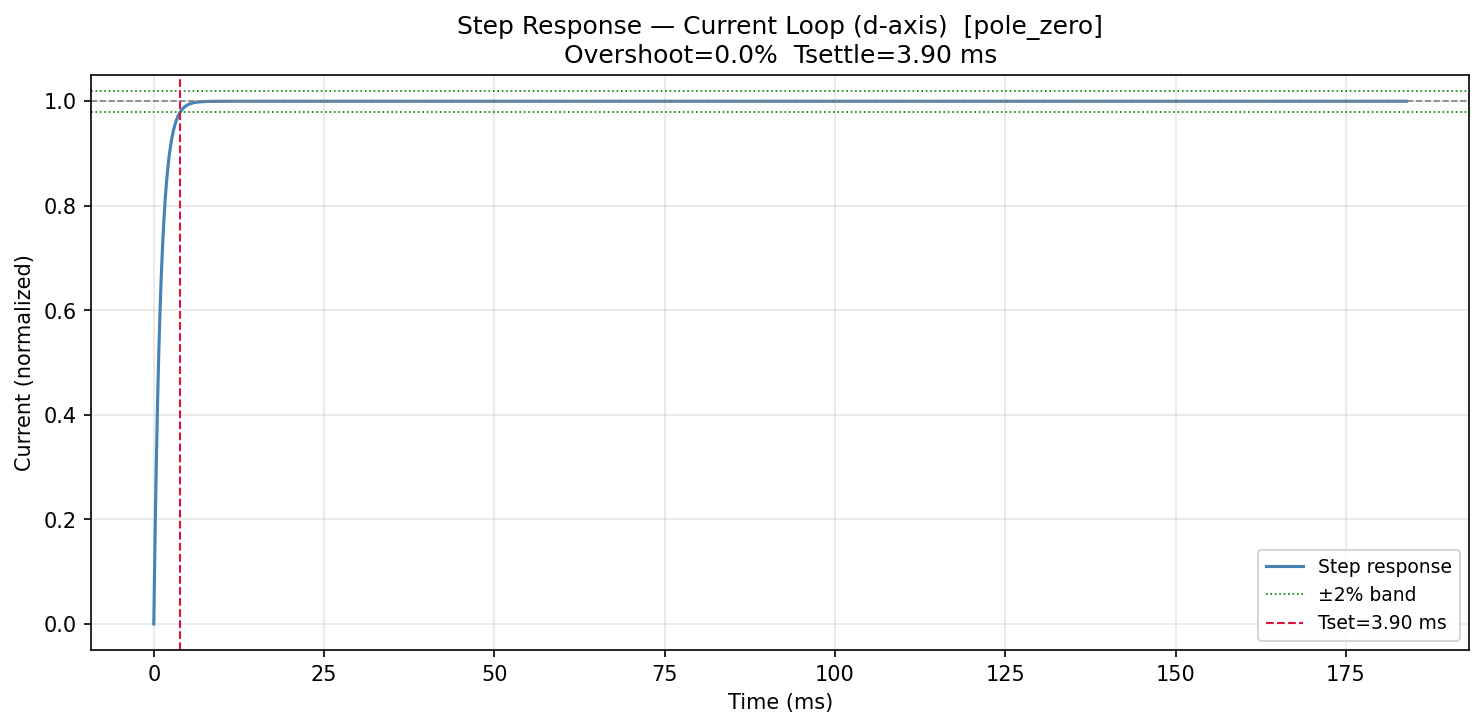

Saved: ../outputs/step_current_frequency_domain.png
--- frequency_domain ---


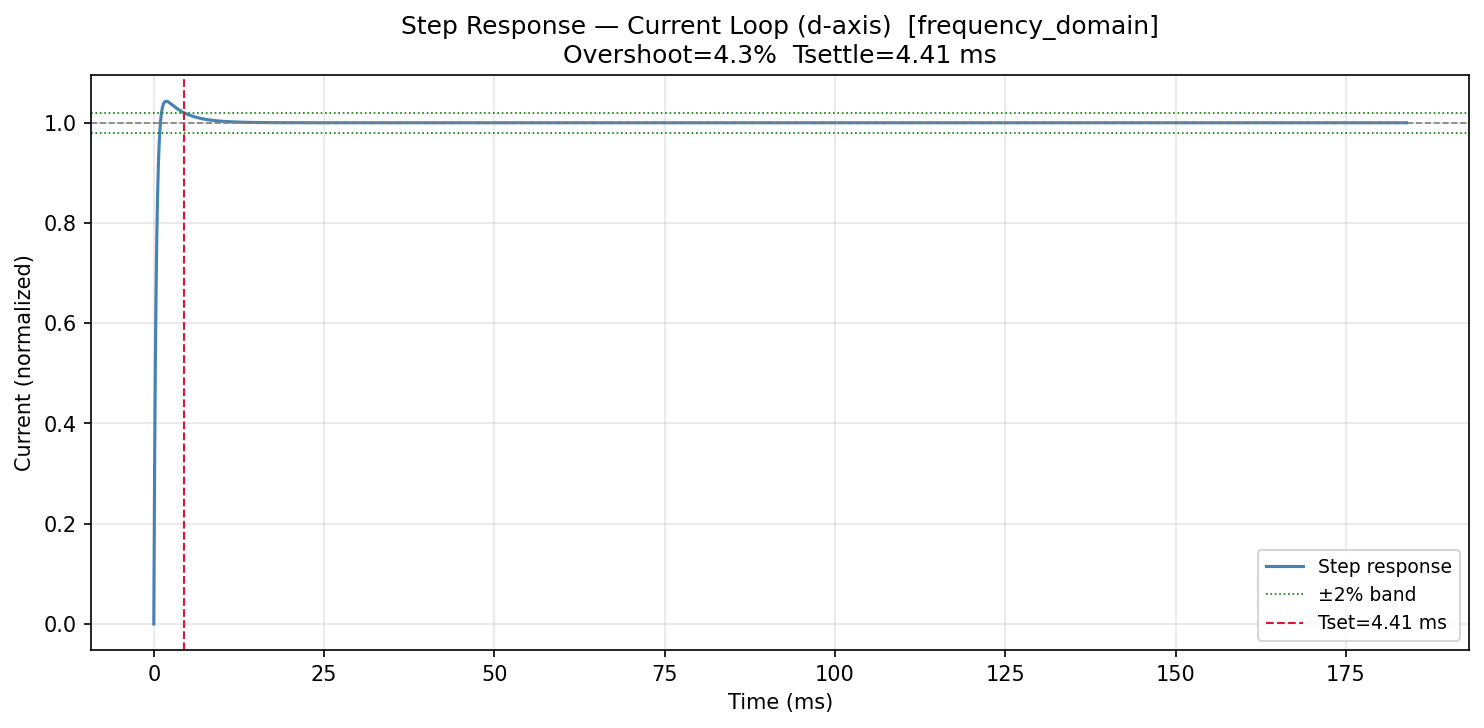

Saved: ../outputs/step_current_root_locus.png
--- root_locus ---


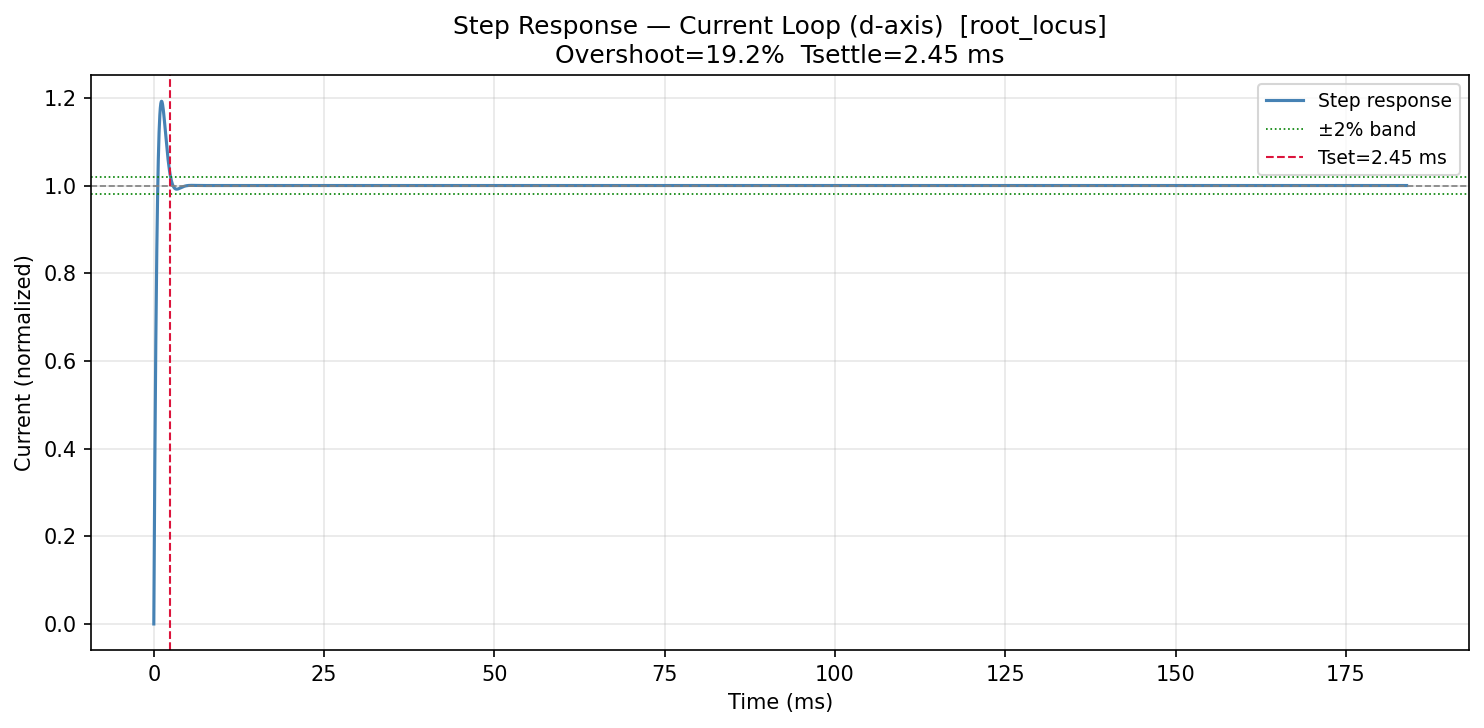

Saved: ../outputs/step_current_ziegler_nichols.png
--- ziegler_nichols ---


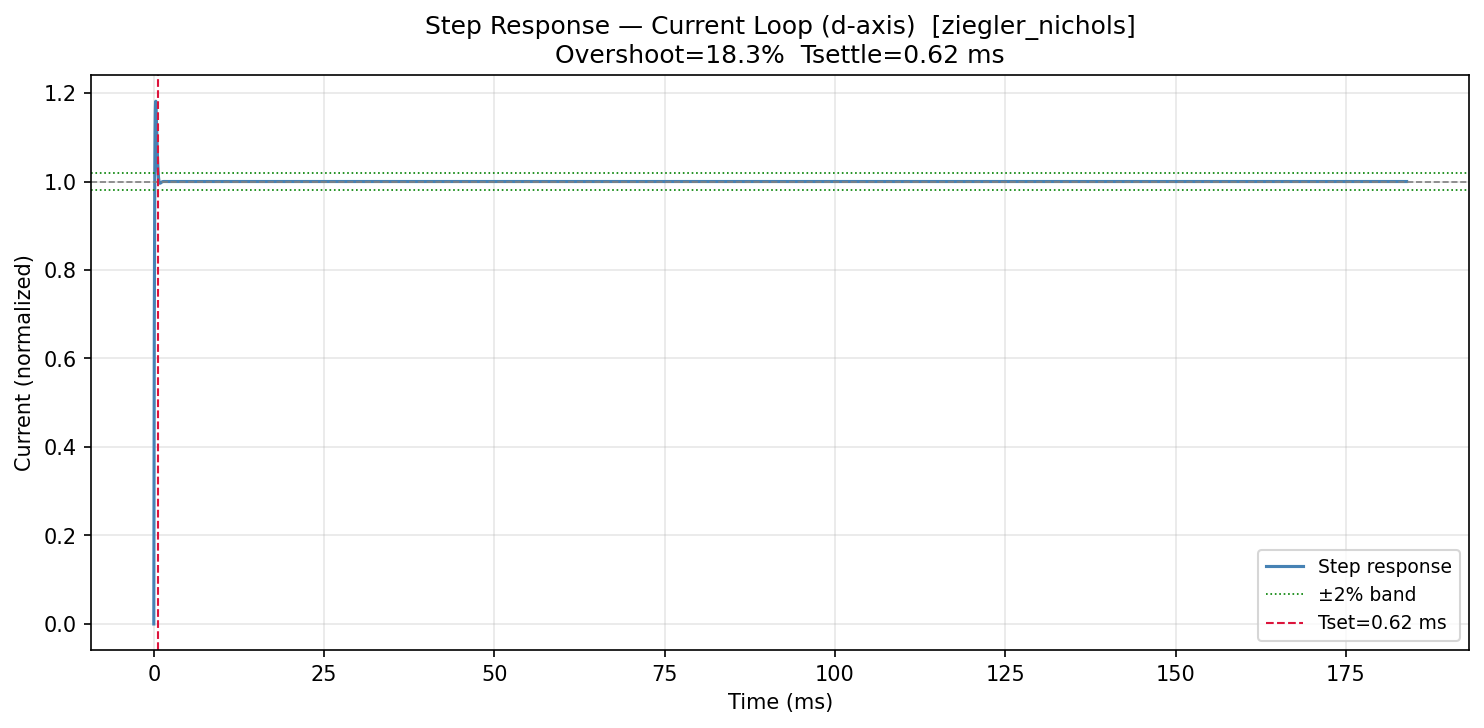

In [10]:
for name, r in results_i.items():
    out = f'../outputs/step_current_{name}.png'
    r.plot_step(save_path=out)
    print(f'--- {name} ---')
    display(Image(out))

## Cell 7 — Pick best method, tune d and q axes

In [11]:
# Pick the method you want to use downstream
CHOSEN_METHOD = 'pole_zero' #root_locus             
TAU_CL = 1e-3   # closed-loop time constant (s)

i_loop_d = tuner_i.tune(CHOSEN_METHOD, axis='d', tau_cl_s=TAU_CL)
i_loop_q = tuner_i.tune(CHOSEN_METHOD, axis='q', tau_cl_s=TAU_CL)

print('D-axis:')
i_loop_d.summary()
print('\nQ-axis:')
i_loop_q.summary()

D-axis:
Method             Axis        Kp       Ki   BW_Hz  PM_deg   GM_dB  Tset_ms
---------------------------------------------------------------------------
pole_zero          d       1.8576   202.01   158.8    90.0     inf    3.897

Q-axis:
Method             Axis        Kp       Ki   BW_Hz  PM_deg   GM_dB  Tset_ms
---------------------------------------------------------------------------
pole_zero          q       1.8576   202.01   158.8    90.0     inf    3.897


## Cell 8 — Discretization analysis

In [12]:
Ts = 50e-6   # 20 kHz PWM
disc = Discretizer(i_loop_d, Ts_s=Ts)

# Tustin vs ZOH comparison
disc_results = disc.compare_methods()

# PWM delay effect
delay_results = disc.pwm_delay_analysis()

# Q15 quantization
q15_results = disc.q15_word_length()

# Firmware-ready table
disc.firmware_table()


--- Discretization Comparison  (Ts=50.0 µs, fc=159.4 Hz) ---
  Method           Kp_d         Ki_d   Phase_loss     PM_eff
  ----------------------------------------------------------
  Continuous    1.85759     202.0106      0.0 deg       90.0
  tustin        1.85759     0.005050       0.00 deg       90.0
  zoh           1.85759     0.010101       0.02 deg       90.0

--- PWM Delay Analysis (1.5×Ts = 75.0 µs) ---
  Crossover frequency : 159.4 Hz
  Phase loss at fc    : 4.3 deg
  PM (no delay)       : 90.0 deg
  PM (with 1.5Ts lag) : 85.7 deg
  BW_max (1/6Ts rule) : 3333.3 Hz

--- Q15 Word-Length Analysis ---
  Param         Float    Scale  Q15 int    Q15 float  Error %  Hex
  ------------------------------------------------------------------------
  Kp         1.857585   0.5000    30435     1.857605   0.0011%  0x76E3
  Ki       202.010643 0.003906    25857   202.007812   0.0014%  0x6501

--- Q15 Word-Length Analysis ---
  Param         Float    Scale  Q15 int    Q15 float  Error %  He

'\n--- Firmware Parameter Table ---\n  Param        Continuous       Tustin_d    Q15_hex\n  --------------------------------------------------\n  Kp             1.857585       1.857585     0x76E3\n  Ki           202.010643       0.005050     0x6501\n  Ts = 50.0 µs   axis = d   method = pole_zero'

## Cell 9 — Bode with delay + discretization comparison plots

Saved: ../outputs/bode_with_delay.png


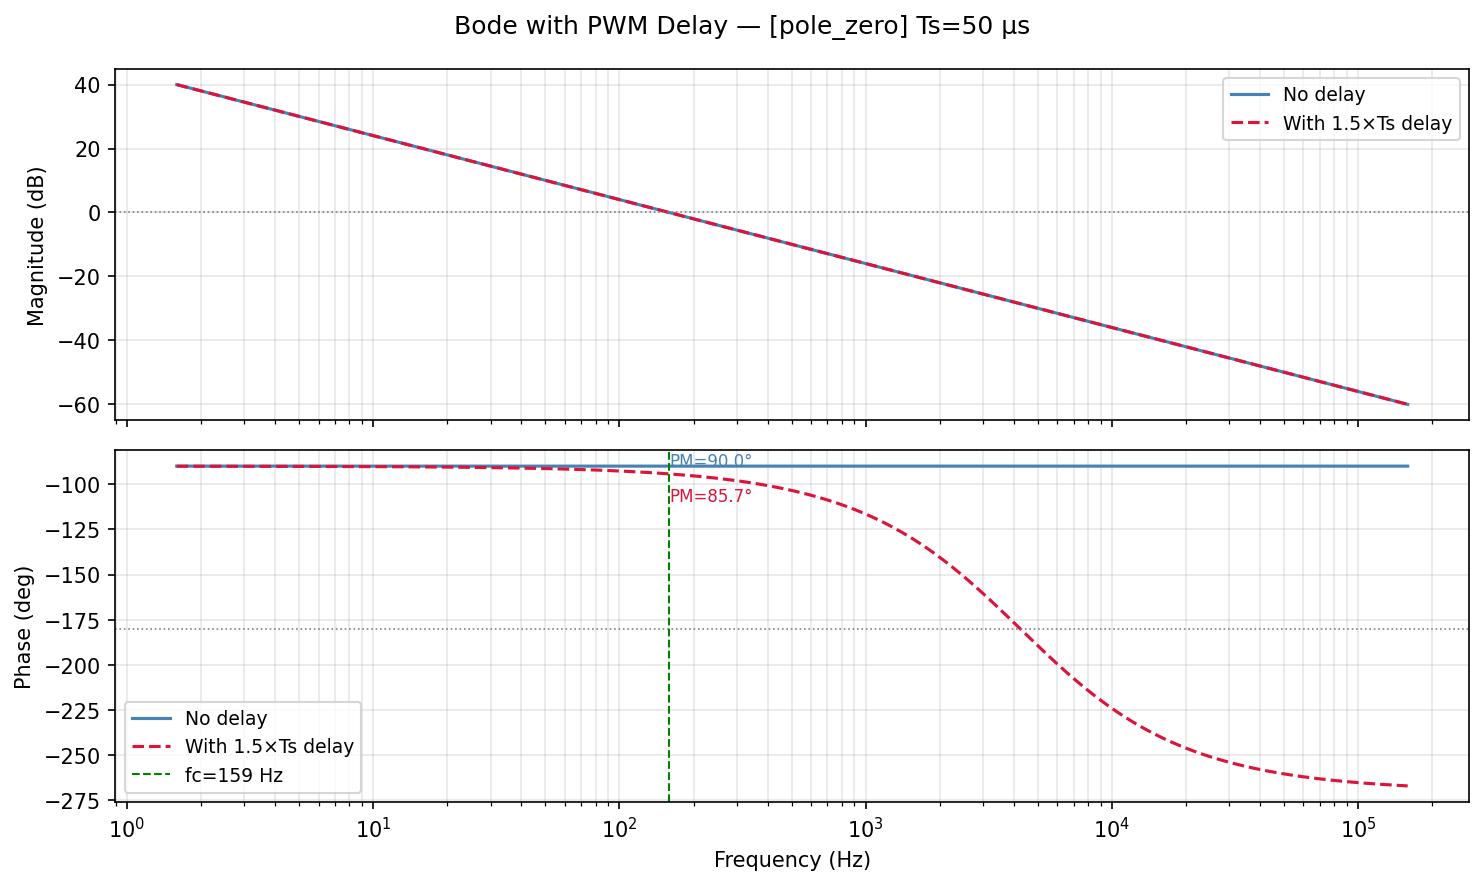

Saved: ../outputs/disc_compare.png


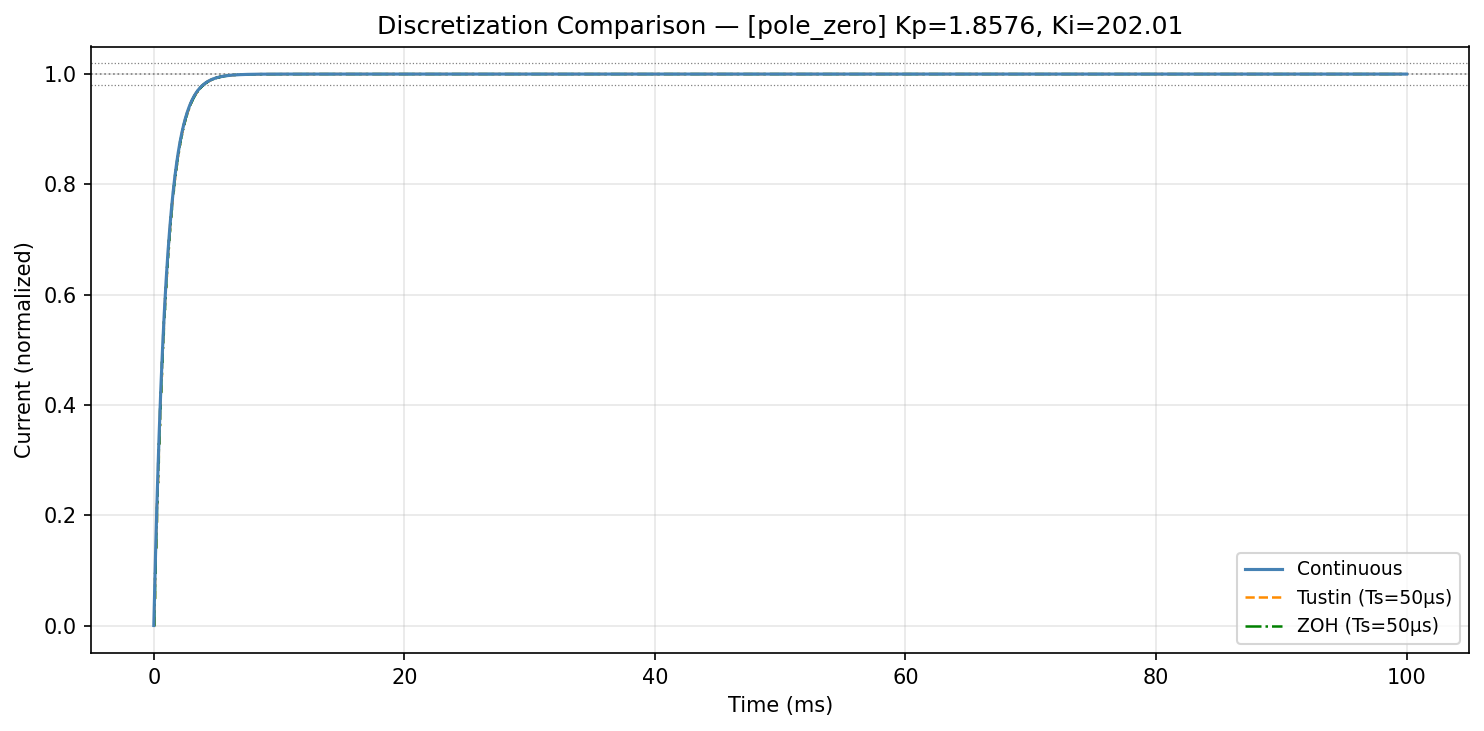

In [13]:
out = '../outputs/bode_with_delay.png'
disc.plot_bode_with_delay(save_path=out)
display(Image(out))

out = '../outputs/disc_compare.png'
disc.plot_discretization_comparison(save_path=out)
display(Image(out))

## Cell 10 — Root locus (current loop)

Saved: ../outputs/root_locus_current.png


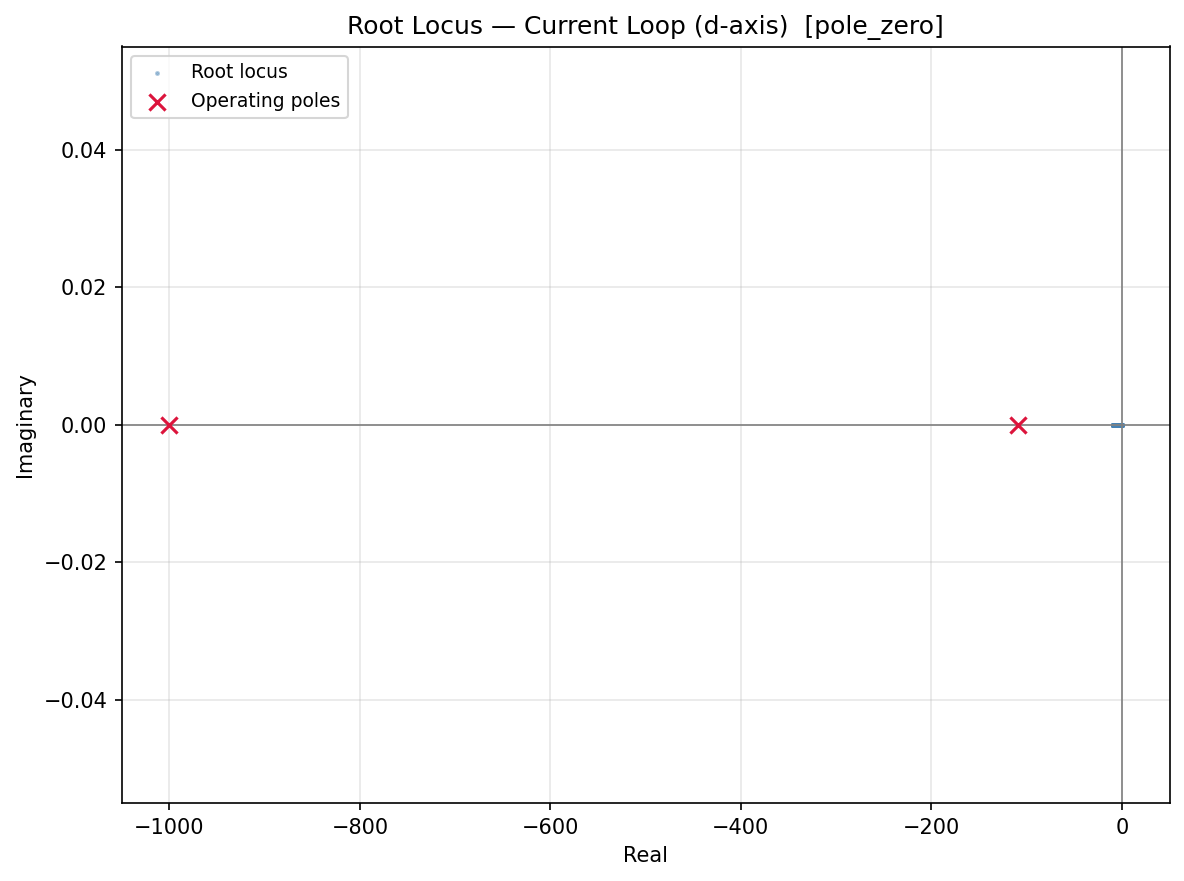

In [14]:
out = '../outputs/root_locus_current.png'
i_loop_d.plot_root_locus(save_path=out)
display(Image(out))

## Cell 11 — Speed loop: all 4 methods compared

In [15]:
tuner_w = SpeedLoopTuner(plant, params, i_loop_d)

results_w = {
    'pole_zero':         tuner_w.tune('pole_zero',        tau_cl_s=50e-3),
    'frequency_domain':  tuner_w.tune('frequency_domain', BW_Hz=30),
    'root_locus':        tuner_w.tune('root_locus',       target_zeta=0.707, tau_cl_s=50e-3),
    'ziegler_nichols':   tuner_w.tune('ziegler_nichols'),
}

print(f"{'Method':<20} {'Kp':>10} {'Ki':>10} {'BW_Hz':>8} {'PM_deg':>8} {'GM_dB':>8} {'Tset_ms':>9} {'Kb':>8}")
print('-' * 85)
for name, r in results_w.items():
    gm = f'{r.GM_dB:.1f}' if r.GM_dB < 900 else 'inf'
    print(f"{name:<20} {r.Kp:>10.4f} {r.Ki:>10.4f} {r.BW_Hz:>8.1f} {r.PM_deg:>8.1f} {gm:>8} {r.settling_ms:>9.1f} {r.Kb:>8.4f}")
    for w in r.warnings:
        print(f'  {w}')

Method                       Kp         Ki    BW_Hz   PM_deg    GM_dB   Tset_ms       Kb
-------------------------------------------------------------------------------------
pole_zero                0.0827     0.6274      4.4     69.1      inf     395.0   7.5822
frequency_domain         0.7897    14.8850     40.3     73.6      inf      86.7  18.8496
root_locus               0.1170     1.6548      6.7     63.7      inf     253.9  14.1443
ziegler_nichols         25.3059 17474.3628    604.8      6.5      inf      27.4 690.5248


## Cell 12 — Speed loop Bode and step plots

Saved: ../outputs/bode_speed.png


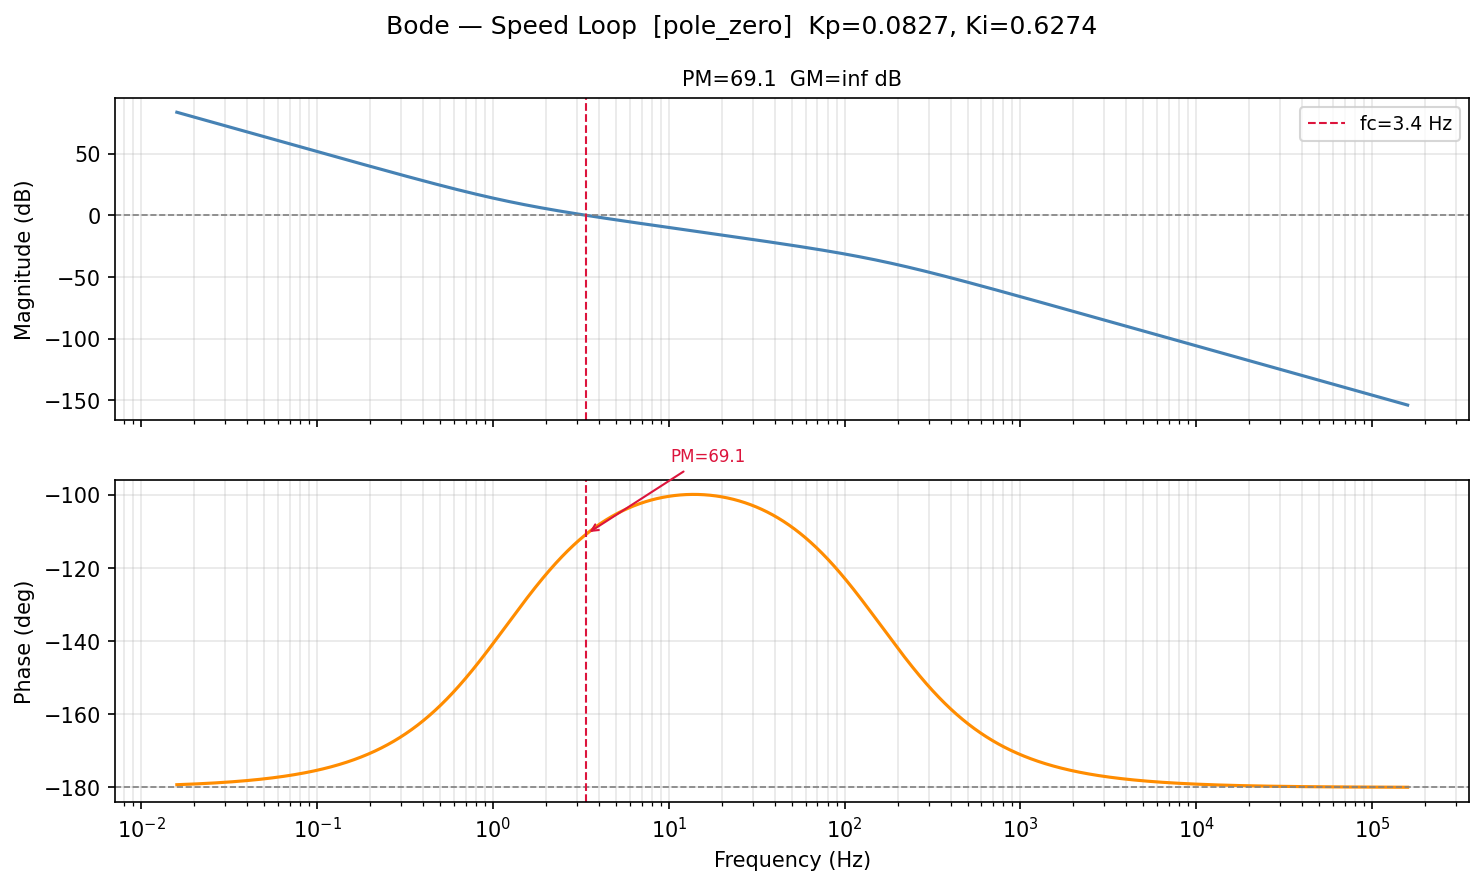

Saved: ../outputs/step_speed.png


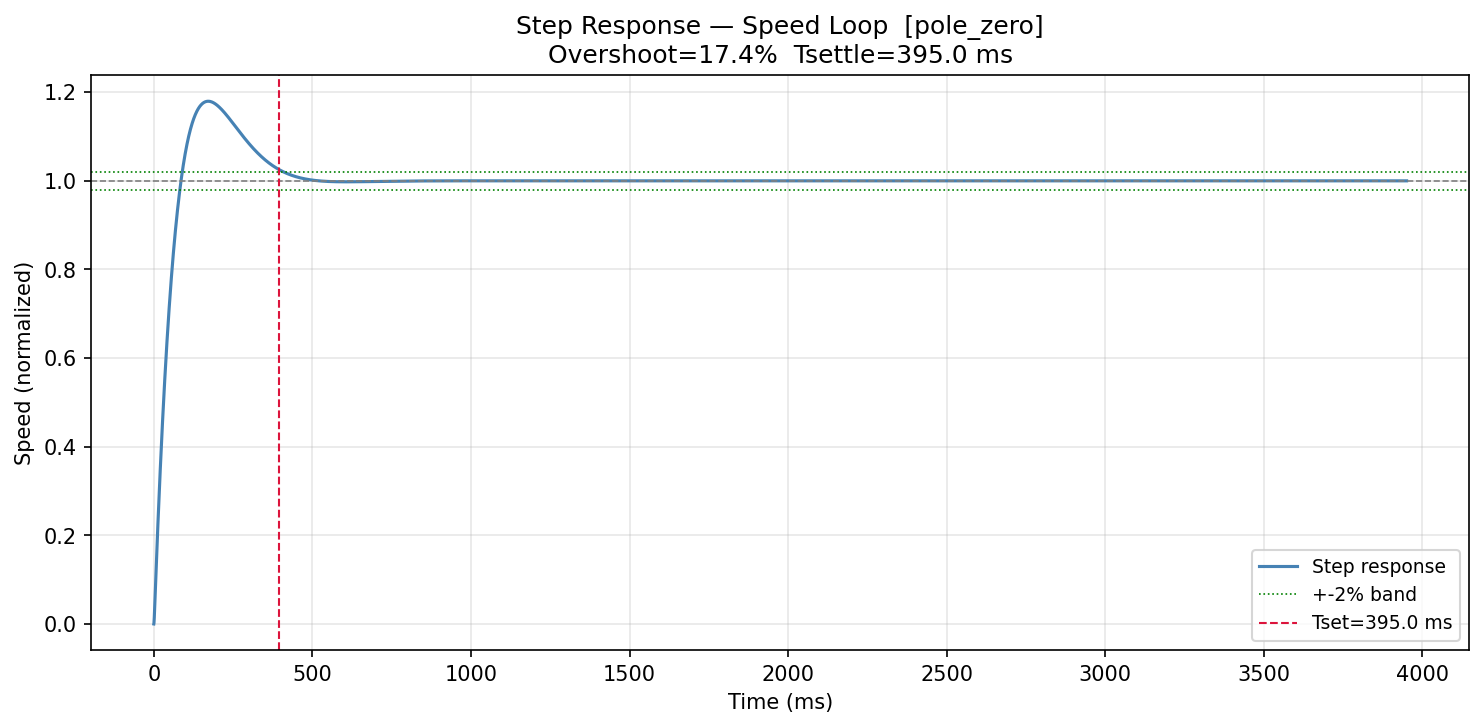

In [16]:
# Pick best speed loop result for downstream use
CHOSEN_W_METHOD = 'pole_zero'
w_loop = results_w[CHOSEN_W_METHOD]

out = '../outputs/bode_speed.png'
tuner_w.plot_bode(w_loop, save_path=out)
display(Image(out))

out = '../outputs/step_speed.png'
tuner_w.plot_step(w_loop, save_path=out)
display(Image(out))

## Cell 13 — Anti-windup comparison

Saved: ../outputs/antiwindup_speed.png


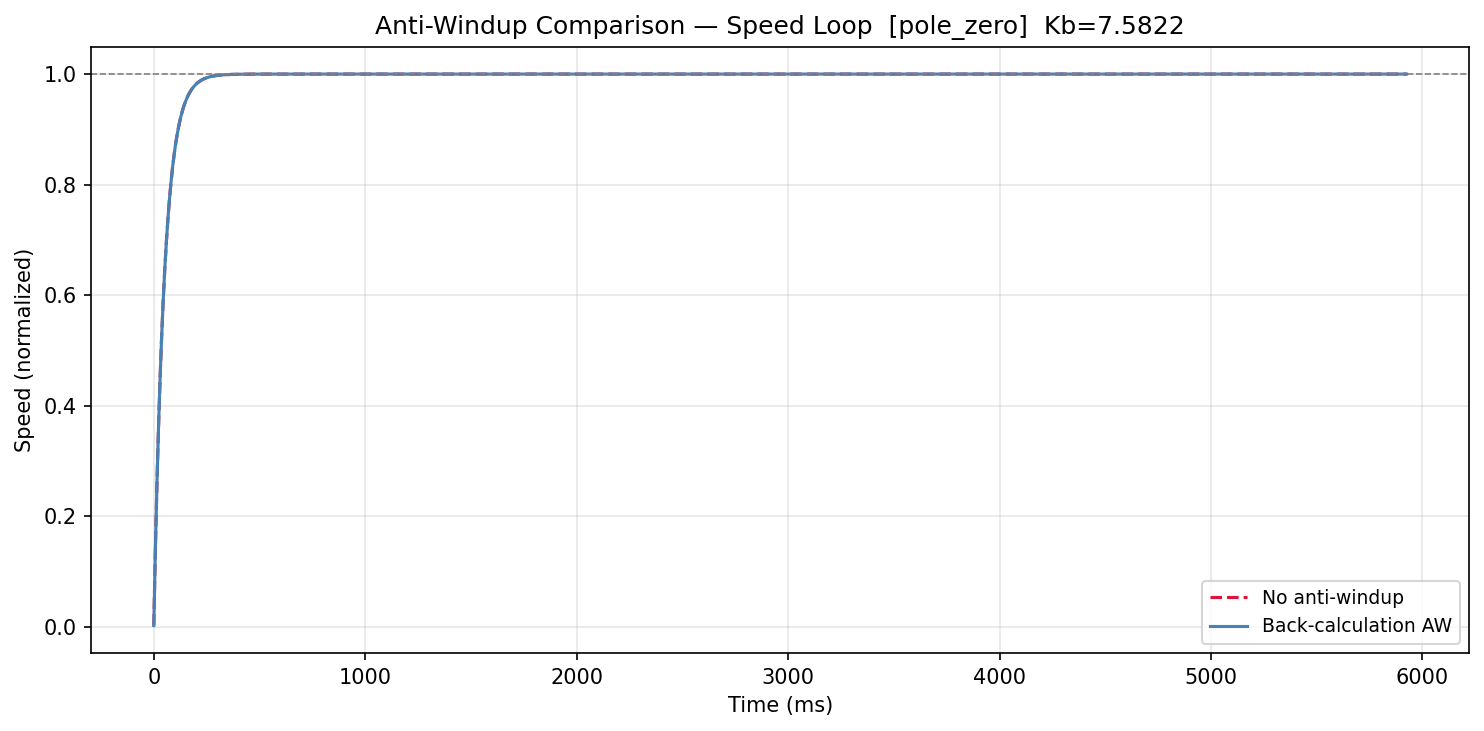

In [17]:
out = '../outputs/antiwindup_speed.png'
tuner_w.plot_antiwindup(w_loop, save_path=out)
display(Image(out))

## Cell 14 — Robustness: parameter sweep

Saved: ../outputs/robustness_sweep.png
Nominal PM = 90.1 deg   GM = 999.0 dB


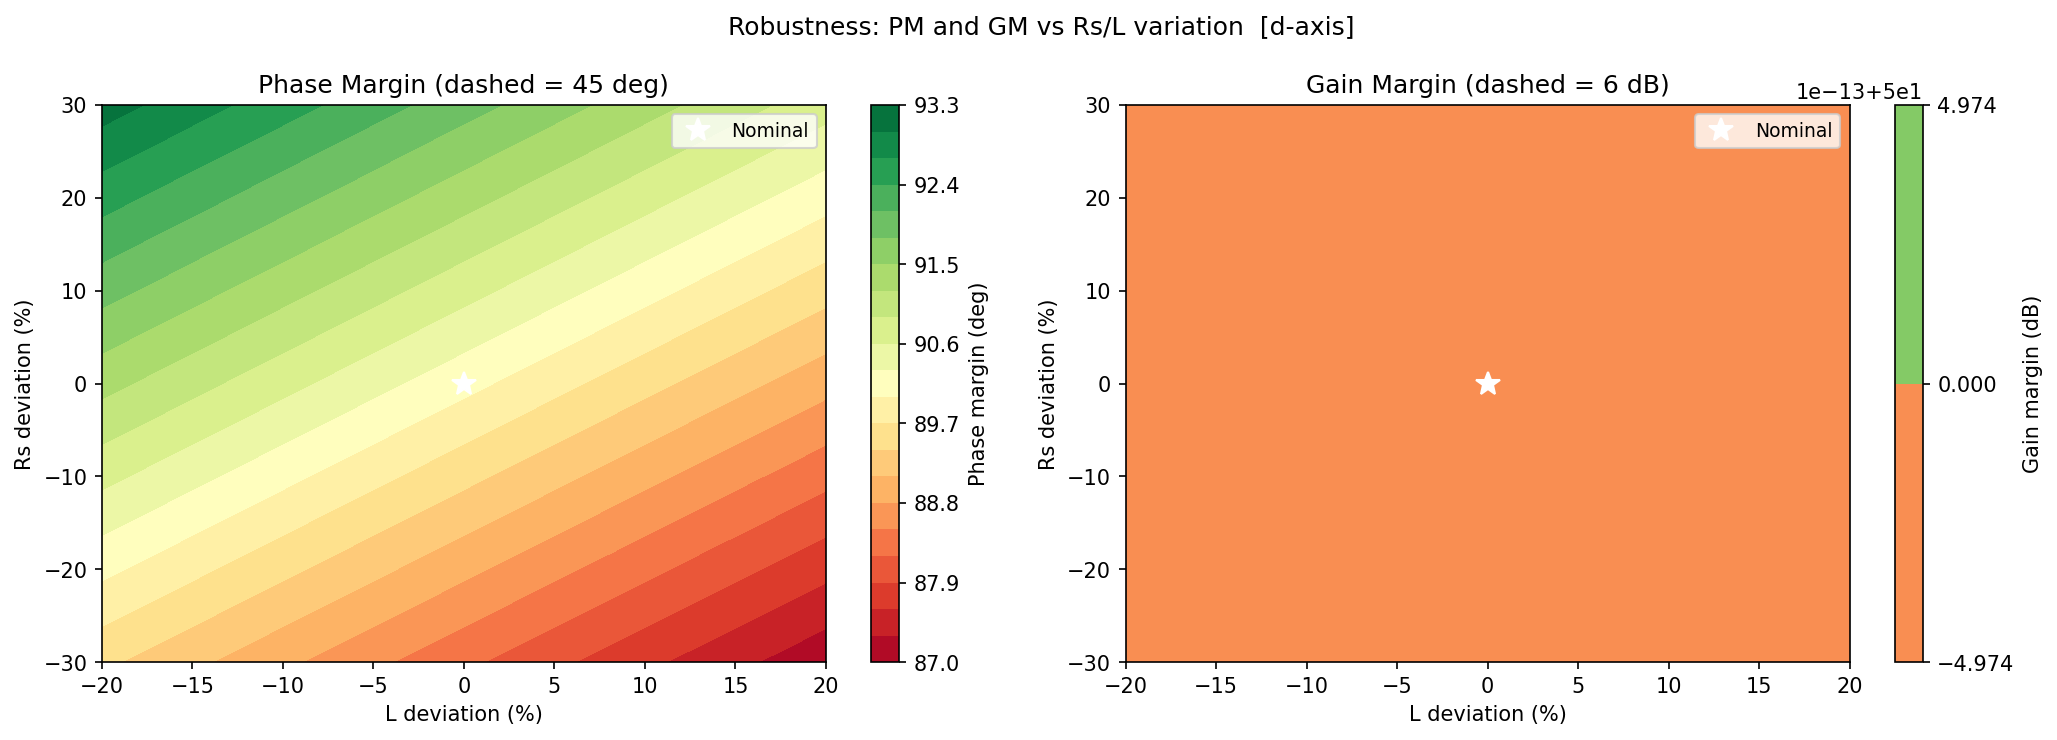

In [18]:
rob = RobustnessAnalyser(plant, i_loop_d, w_loop)

out = '../outputs/robustness_sweep.png'
sweep = rob.parameter_sweep(
    Rs_range=(-0.3, 0.3),
    L_range=(-0.2, 0.2),
    steps=21,
    axis='d',
    save_path=out,
)
print(f"Nominal PM = {sweep['nominal_PM']:.1f} deg   GM = {sweep['nominal_GM']:.1f} dB")
display(Image(out))

## Cell 15 — Sensitivity functions

Saved: ../outputs/sensitivity.png
Peak sensitivity Ms = -0.00 dB @ 1591549 Hz


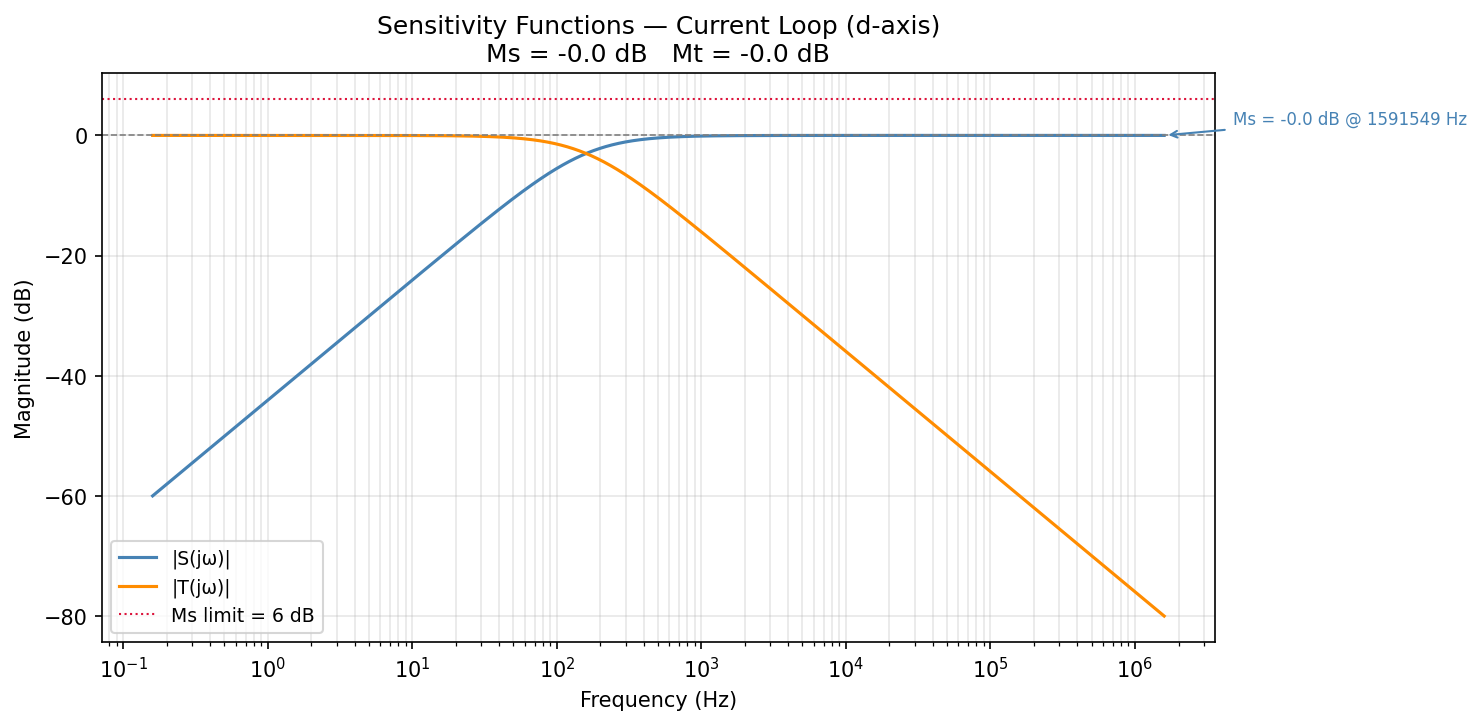

In [19]:
out = '../outputs/sensitivity.png'
sens = rob.sensitivity(axis='d', save_path=out)
print(f"Peak sensitivity Ms = {sens['Ms_dB']:.2f} dB @ {sens['Ms_Hz']:.0f} Hz")
for w in sens['warnings']:
    print(w)
display(Image(out))

## Cell 16 — Margin waterfall

Saved: ../outputs/margin_waterfall.png


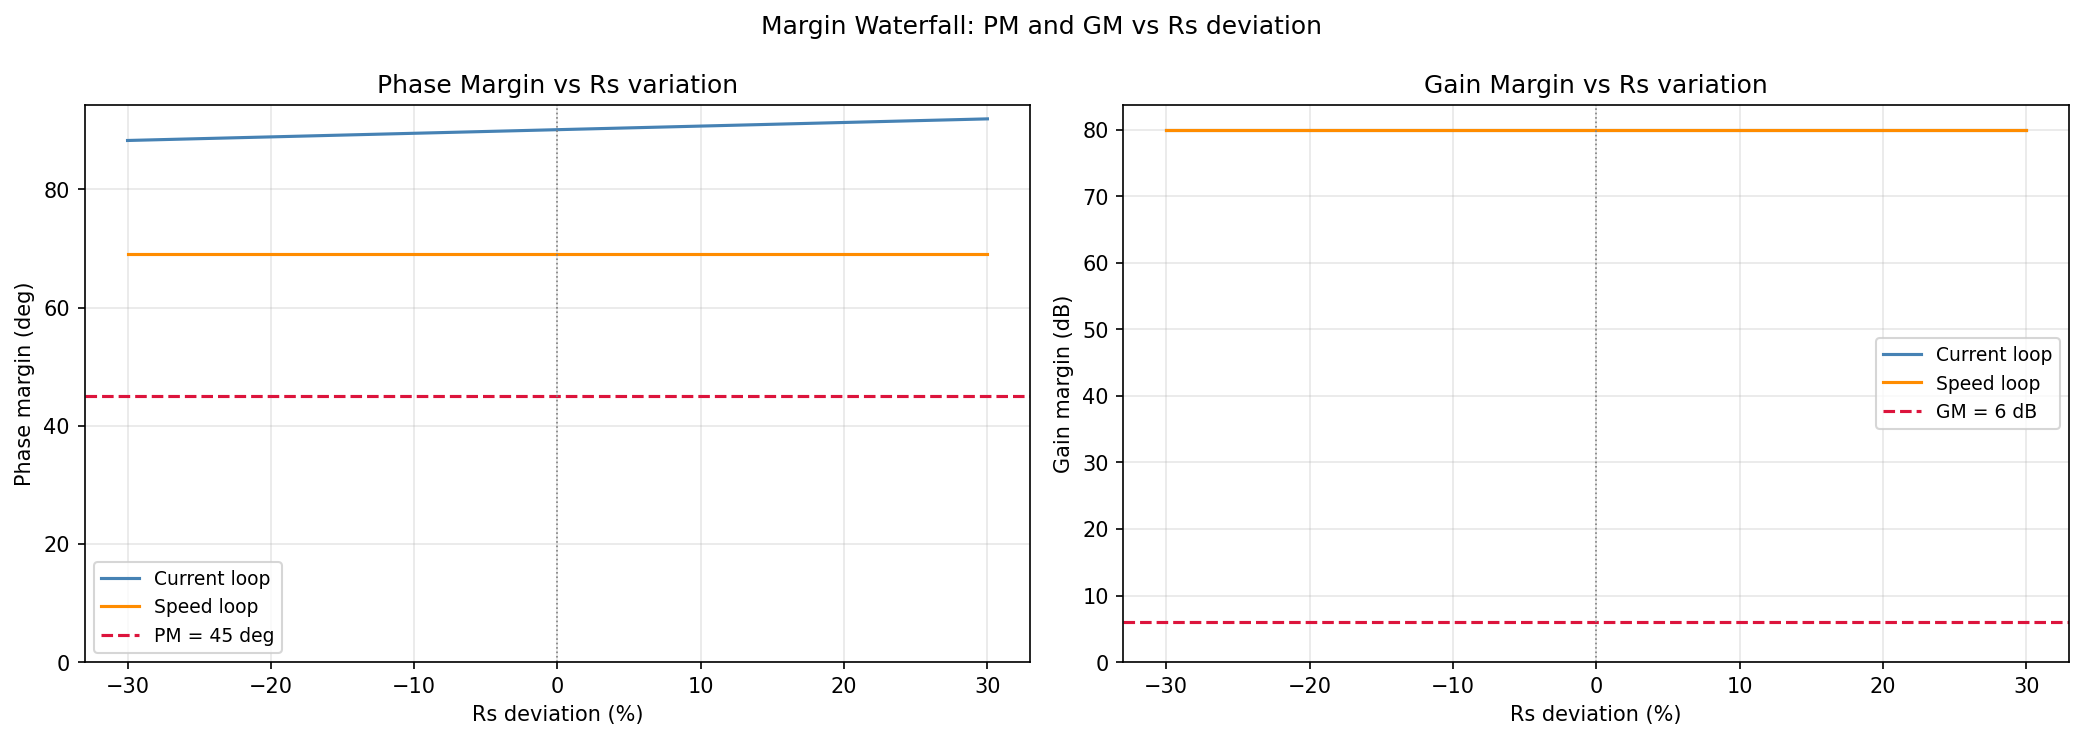

In [20]:
out = '../outputs/margin_waterfall.png'
wf = rob.margin_waterfall(Rs_range=(-0.3, 0.3), steps=31, axis='d', save_path=out)
display(Image(out))

## Cell 17 — Full dashboard + CSV export

Saved: ../outputs\dashboard_motor_load.png
Saved: ../outputs\gains_summary_motor_load.csv
Dashboard: dashboard_motor_load.png
CSV      : gains_summary_motor_load.csv


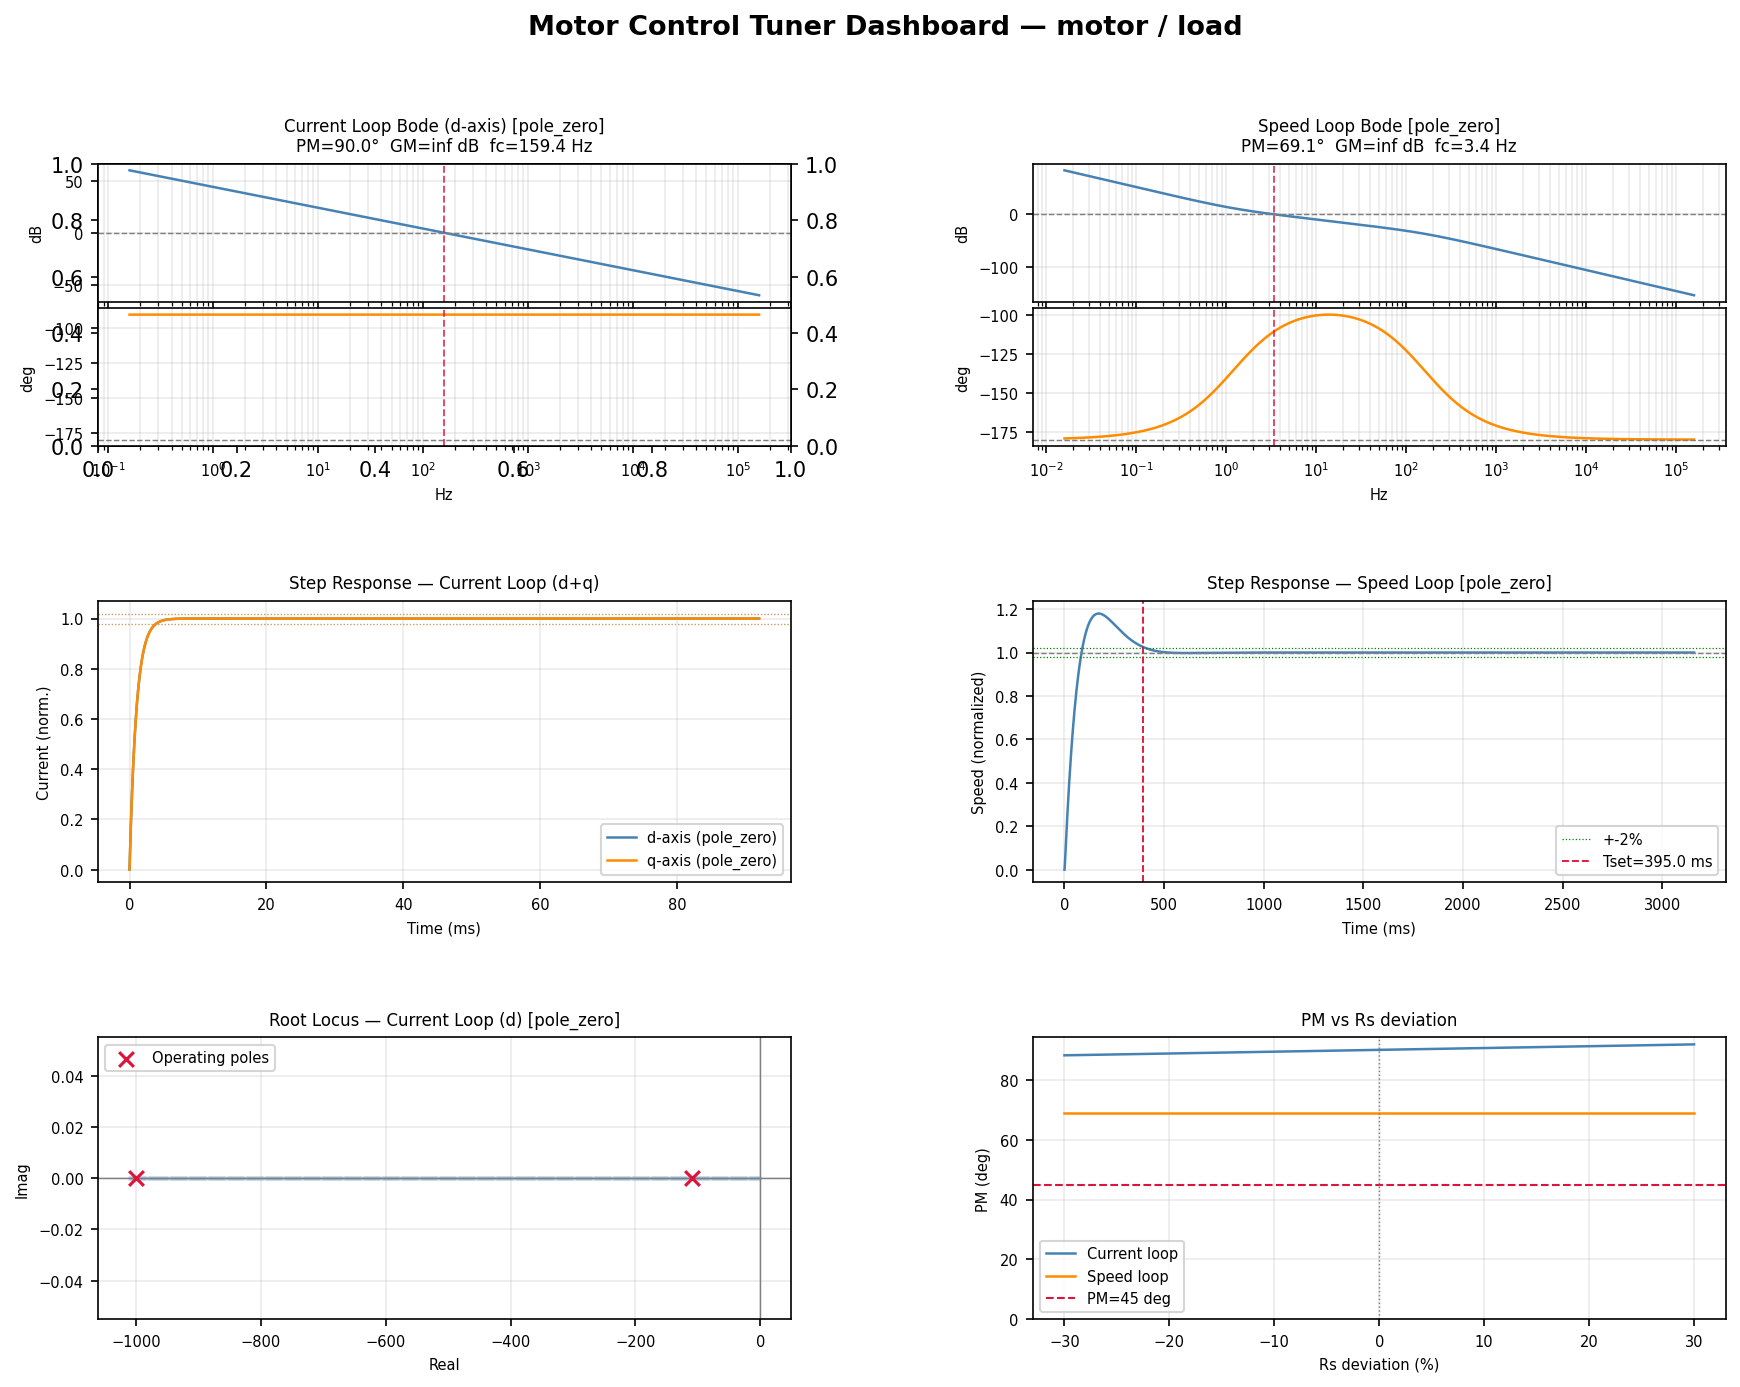

current_d    Kp=1.8576  Ki=202.0106  BW=158.8 Hz  PM=90.0 deg
current_q    Kp=1.8576  Ki=202.0106  BW=158.8 Hz  PM=90.0 deg
speed        Kp=0.0827  Ki=0.6274  BW=4.4 Hz  PM=69.1 deg


In [21]:
from modules.dashboard import generate_dashboard

generate_dashboard(
    params,
    i_loop_d,
    i_loop_q,
    w_loop,
    plant=plant,
    save=True,
    output_dir='../outputs',
)

import glob, os, csv as _csv
png = sorted(glob.glob('../outputs/dashboard_*.png'))[-1]
csv_f = sorted(glob.glob('../outputs/gains_summary_*.csv'))[-1]
print(f'Dashboard: {os.path.basename(png)}')
print(f'CSV      : {os.path.basename(csv_f)}')
display(Image(png))

# Print CSV contents
with open(csv_f) as f:
    for row in _csv.DictReader(f):
        print(f"{row['loop']:<12} Kp={float(row['Kp']):.4f}  Ki={float(row['Ki']):.4f}  "
              f"BW={float(row['BW_Hz']):.1f} Hz  PM={float(row['PM_deg']):.1f} deg")

## Cell 18 — Position loop (servo load)

Reloads config with `load_position_servo.yaml`, rebuilds the current and speed loops,
then tunes P and PD position controllers.

**BW hierarchy:** BW_pos ≤ BW_speed / 10 ≤ BW_current / 100

**Velocity feedforward:** `Kff_v=1.0` eliminates steady-state ramp following error.

In [24]:
# Reload with servo load (position loop requires this load type)
servo_motor_cfg, servo_load_cfg = load_config(
    '../config/motor_delta_ecma_c21010.yaml',   # swap to BLQ-40 if desired
    '../config/load_position_servo.yaml'
)
servo_plant = PMSMPlant(servo_motor_cfg, servo_load_cfg)

# Full identification with servo load (mechanical: only B_total, no k_fan or TL_const)
servo_pid = ParameterIdentifier(servo_motor_cfg, servo_load_cfg)
servo_params = servo_pid.simulate(noise_std_frac=0.02)
servo_mech   = servo_pid.simulate_mechanical(noise_std_frac=0.02)
print("Servo system identification:")
servo_pid.print_comparison({**servo_params, **servo_mech})

# Current loop (re-tuned for servo plant)
servo_i_loop = CurrentLoopTuner(servo_plant, servo_params).tune(
    'pole_zero', axis='d', tau_cl_s=1e-3
)
print(f" Current loop: BW={servo_i_loop.BW_Hz:.1f} Hz  PM={servo_i_loop.PM_deg:.1f} deg")

# Speed loop
servo_w_loop = SpeedLoopTuner(servo_plant, servo_params, servo_i_loop).tune(
    'pole_zero', tau_cl_s=50e-3
)
print(f" Speed loop  : BW={servo_w_loop.BW_Hz:.2f} Hz  PM={servo_w_loop.PM_deg:.1f} deg")

# Position loop — P and PD
tuner_pos = PositionLoopTuner(servo_plant, servo_w_loop)

pos_P  = tuner_pos.tune('P',  Kff_v=1.0)
pos_PD = tuner_pos.tune('PD', zeta=0.7, Kff_v=1.0)

# Comparison table
print(f" {'Method':<6} {'Kp':>8} {'Kd':>8} {'BW_Hz':>7} {'PM_deg':>8} {'GM_dB':>7} {'settle_ms':>10} {'e_ss_ramp':>10}")
print('-' * 68)
for label, r in [('P', pos_P), ('PD', pos_PD)]:
    gm = f'{r.GM_dB:.1f}' if r.GM_dB < 900 else 'inf'
    print(f"{label:<6} {r.Kp:>8.4f} {r.Kd:>8.4f} {r.BW_Hz:>7.3f} {r.PM_deg:>8.1f} "
          f"{gm:>7} {r.settling_ms:>10.1f} {r.following_error_ramp:>10.4f}")
    for w in r.warnings:
        print(f'  {w}')

Servo system identification:

Parameter Identification Summary [simulated_mechanical]
Motor: Delta ECMA-C21010
Param              True     Measured  Error %  Unit
----------------------------------------------------
Rs               0.2000       0.2020    +1.01%  Ohm
Ld               1.8100       1.8576    +2.63%  mH
Lq               1.8100       1.9117    +5.62%  mH
psi_f           43.6000      42.7036    -2.06%  mWb

tau_d = 9.195 ms
tau_q = 9.463 ms

Mechanical Identification Summary
  Motor:  J_motor=2.6500e-04 kg.m2  B_motor=0.00100 N.m.s/rad
  Load:   J_load_true=1.0000e-03 kg.m2  B_load_true=0.00000 N.m.s/rad

Param                True       Measured  Error %  Unit
----------------------------------------------------------
p                  4.0000         4.0000    +0.00%  -
KE_SI              0.1744         0.1719    -1.41%  V.s/rad
psi_f_ke          43.6000        42.9870    -1.41%  mWb
J_total           12.6500        12.6298    -0.16%  x1e-4 kg.m2
J_load            10.0000 

In [25]:
# Bode and step plots — P vs PD
for label, r in [('P', pos_P), ('PD', pos_PD)]:
    bode_out = f'../outputs/bode_position_{label}.png'
    step_out = f'../outputs/step_position_{label}.png'
    r.plot_bode()
    r.plot_step()
    # Save via matplotlib if the methods don't accept save_path
    import glob
    print(f'--- Position {label}: PM={r.PM_deg:.1f} deg  settle={r.settling_ms:.1f} ms ---')

h:\My Drive\motor-control-tuner\modules\position_loop.py:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
h:\My Drive\motor-control-tuner\modules\position_loop.py:145: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


--- Position P: PM=84.3 deg  settle=1688.7 ms ---
--- Position PD: PM=138.7 deg  settle=4739.7 ms ---


---
## Summary

All gains are in `outputs/gains_summary_*.csv`.

**Full identification pipeline:**

| Cell | Stage | Parameters identified |
| --- | --- | --- |
| 3 | Electrical ID | Rs, Ld, Lq, psi_f |
| 4 | Mechanical ID | p, KE_SI, J_total, J_load, B_total, k_fan / TL_const |

**Full control design pipeline:**
```
config → plant → elec_id → mech_id → current_loop → discretization
       → speed_loop → robustness → position_loop → dashboard
```

| Loop | Module | Key outputs |
| --- | --- | --- |
| Current (d/q) | `current_loop.py` | Kp, Ki per axis |
| Speed | `speed_loop.py` | Kp, Ki, Kb (anti-windup) |
| Position | `position_loop.py` | Kp, Kd, Kff_v |

Use `run_all.py` to regenerate all outputs for both motors × all loads.